The Netflix Movies and TV Shows dataset from Kaggle was used for this analysis. It contains information about Netflix content, including titles, content type, country, release year, ratings, and dates added to the platform. The dataset was analyzed to identify content trends, distribution patterns, and key business insights through exploratory data analysis and visualizations.


In [18]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [21]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

print("Shape:", df.shape)
print("\nData Types:",df.dtypes)

print("\nMissing Values:",df.isnull().sum())

print("\nDuplicate Rows:",df.duplicated().sum())
print(df.head())
print(df.tail())

Shape: (8807, 12)

Data Types: show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

     

In [23]:
#find missing values
print(df.isnull().sum())

#fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

#Drop rows where date_added is missing
df.dropna(subset=['date_added'], inplace=True)

df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    errors='coerce'
)

#Remove duplicates
df.drop_duplicates(inplace=True)

#Verify once after cleaning
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [24]:
# Q1- Which type of content is more common on Netflix?
print(df['type'].value_counts())

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [25]:
#Q2- Which countries produce the most Netflix content?
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [26]:
#Q3- What are the most common content ratings?
print(df['rating'].value_counts())

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


In [27]:
#Q4- How has Netflix content grown over time?
df['year_added'] = df['date_added'].dt.year
content_by_year = df.groupby('year_added')['show_id'].count()
print(content_by_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


In [28]:
#Q5- Which release years have the most titles?
print(df['release_year'].value_counts().head(10))

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
2021     592
2015     558
2014     352
2013     287
2012     236
Name: count, dtype: int64


In [29]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

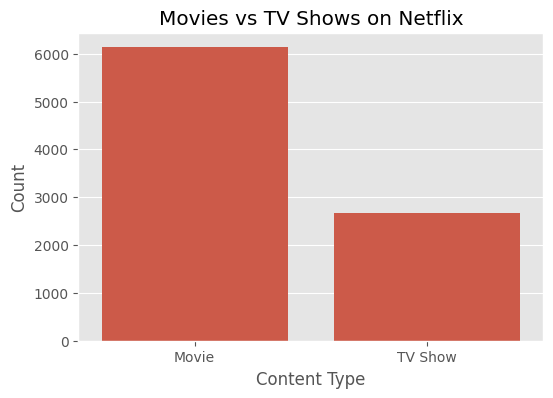

In [30]:
#Chart 1 - Bar Chart - Content Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

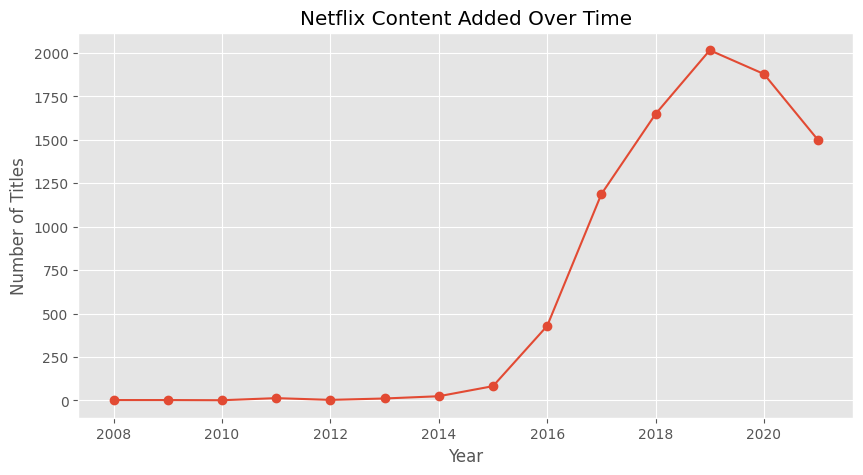

In [31]:
#Chart 2 – Line Chart - Content Added by Year
yearly = df.groupby('year_added')['show_id'].count()
plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

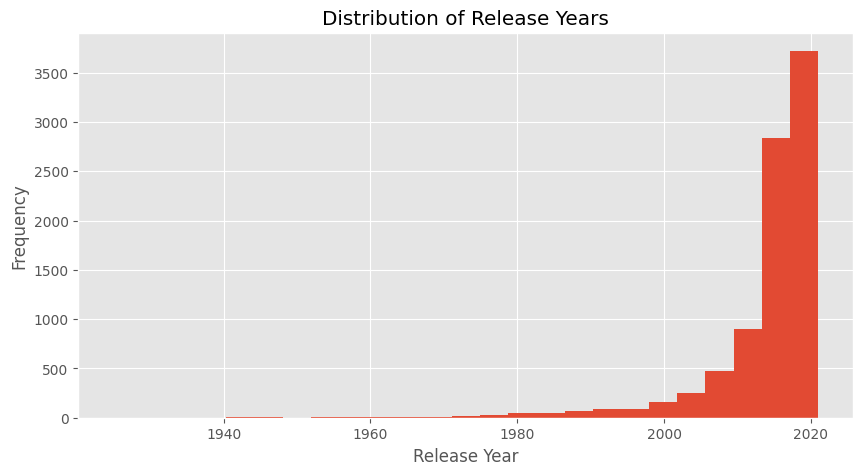

In [32]:
#Chart 3 – Histogram - Release Year Distribution
plt.figure(figsize=(10,5))
plt.hist(df['release_year'], bins=25)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

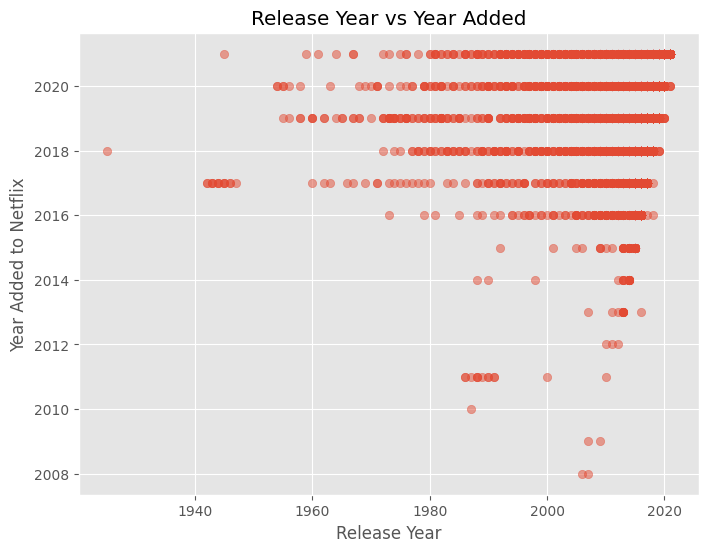

In [33]:
#Chart 4 – Scatter Plot - Release Year vs Added Year
plt.figure(figsize=(8,6))
plt.scatter(
    df['release_year'],
    df['year_added'],
    alpha=0.5
)
plt.title('Release Year vs Year Added')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

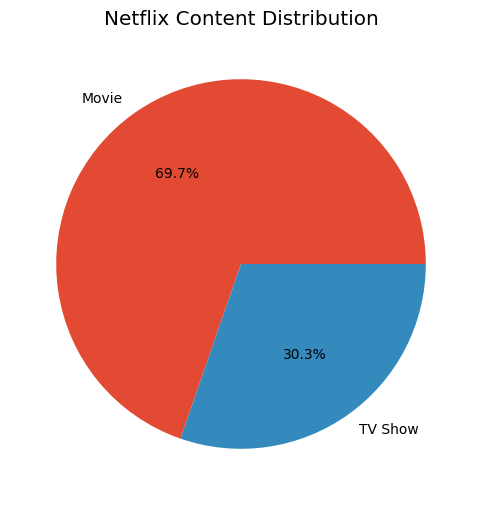

In [34]:
#Chart 5 – Pie Chart - Content Share
content_share = df['type'].value_counts()

plt.figure(figsize=(6,6))

content_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Netflix Content Distribution')
plt.ylabel('')

plt.show()

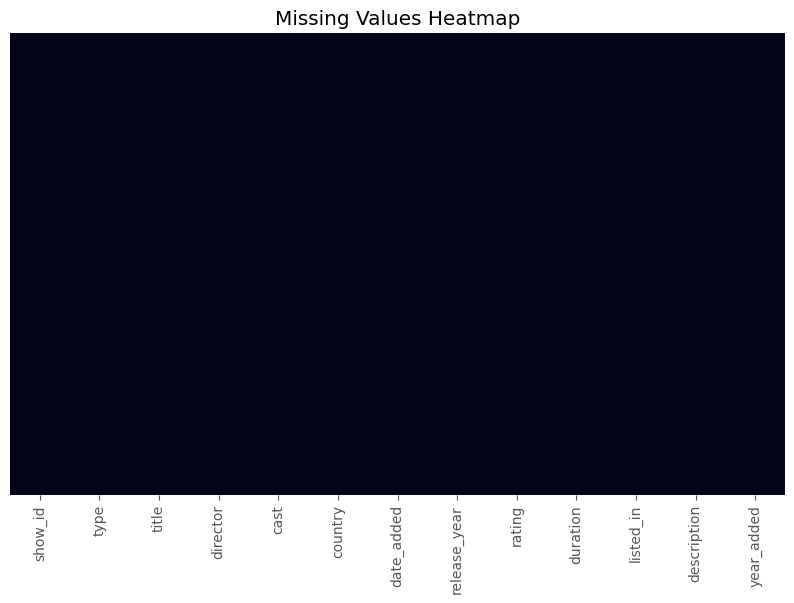

In [35]:
#Chart 6 – Heatmap - Missing Values
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')

plt.show()

NETFLIX DATASET INSIGHTS REPORT

1. Movies Dominate the Platform
The Movies vs TV Shows bar chart shows that movies account for roughly 70% of all titles on Netflix. This indicates that Netflix has historically focused more on acquiring and producing movies than television series.

2. The United States Is the Largest Content Producer

The country analysis revealed that the United States contributes the highest number of titles available on Netflix. This suggests Netflix relies heavily on U.S.-based content while also expanding internationally.

3. Rapid Growth Occurred Between 2016 and 2019

The line chart displaying content additions by year shows a sharp increase in titles added during this period. This reflects Netflix's aggressive global expansion strategy and increased investment in content acquisition.

4. Netflix Primarily Targets Mature Audiences

The ratings analysis indicates that TV-MA and TV-14 are the most common ratings. This suggests Netflix focuses strongly on content intended for teenagers and adults.

5. Most Available Content Is Modern

The release year histogram demonstrates that the majority of Netflix titles were produced after 2000, with particularly high concentrations after 2015. This indicates a preference for contemporary content that aligns with current viewer interests.

BUSINESS RECOMMENDATIONS

1. Increase investment in high-performing TV series to improve viewer retention and subscription renewal rates.

2. Expand content partnerships in countries such as India, South Korea, and Japan where content production is growing rapidly.

3. Continue investing in mature-audience programming while expanding family-friendly content to reach broader demographics.

4. Use successful U.S. content strategies as a model for international productions and regional originals.

5. Prioritize acquisition of recent releases since modern content appears to dominate the catalog and likely matches audience demand.
